In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt

In [2]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [3]:
incedets_master = pd.read_csv("Dados/originais/incidents_master.csv")

In [ ]:
incedets_master.head(3)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [5]:
incedets_master.isnull().sum()

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

In [6]:
incedets_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    str    
 1   company_name              850 non-null    str    
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    str    
 4   industry_primary          850 non-null    str    
 5   industry_secondary        153 non-null    str    
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    str    
 9   incident_date             850 non-null    str    
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    str    
 12  disclosure_date           850 non-null    str    
 13  attack_vector_primary     850 non-null    str    
 14  attack_vector_seconda

In [7]:
incedets_master.describe()

,company_revenue_usd,employee_count,data_compromised_records,downtime_hours,confidence_tier,quality_score
count,8.500000e+02,8.500000e+02,6.020000e+02,420.000000,850.000000,850.000000
mean,1.031337e+10,5.433418e+04,2.708462e+06,107.208762,2.215294,79.963047
std,2.106158e+10,1.266599e+05,2.978069e+07,184.645681,1.202472,12.209540
min,2.424181e+07,6.700000e+01,1.000000e+03,1.830000,1.000000,50.040000
25%,2.327545e+08,1.087000e+03,1.200500e+04,25.822500,1.000000,71.727500
50%,1.261375e+09,6.219500e+03,5.613300e+04,53.600000,2.000000,80.815000
75%,8.692943e+09,4.359475e+04,2.891170e+05,119.800000,3.000000,90.072500
max,1.488980e+11,1.411332e+06,5.497365e+08,1951.620000,4.000000,99.780000


In [8]:
incedets_master_bronze = incedets_master.apply(lambda x: create_bronze_df(x, "incedets_master.parquet"), axis=1)

In [9]:
if Path("Dados/bronze/incedets_master_bronze.parquet").exists() :
    os.remove('Dados/bronze/incedets_master_bronze.parquet')
   

In [10]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [11]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/incedets_master_bronze.parquet").exists()) :
        incedets_master_bronze.to_parquet('incedets_master_bronze.parquet')
        shutil.move('incedets_master_bronze.parquet','Dados/bronze')

In [12]:
print(incedets_master_bronze.isnull().sum()/incedets_master_bronze.shape[0] * 100)

incident_id                  0.000000
company_name                 0.000000
company_revenue_usd          0.000000
country_hq                   0.000000
industry_primary             0.000000
industry_secondary          82.000000
employee_count               0.000000
is_public_company            0.000000
stock_ticker                51.529412
incident_date                0.000000
incident_date_estimated      0.000000
discovery_date               0.000000
disclosure_date              0.000000
attack_vector_primary        0.000000
attack_vector_secondary     75.176471
attack_chain                32.352941
attributed_group            43.294118
attribution_confidence      43.294118
data_compromised_records    29.176471
data_type                   29.176471
systems_affected             0.000000
downtime_hours              50.588235
data_source_primary          0.000000
data_source_secondary       54.588235
data_source_type             0.000000
confidence_tier              0.000000
quality_scor

<Axes: >

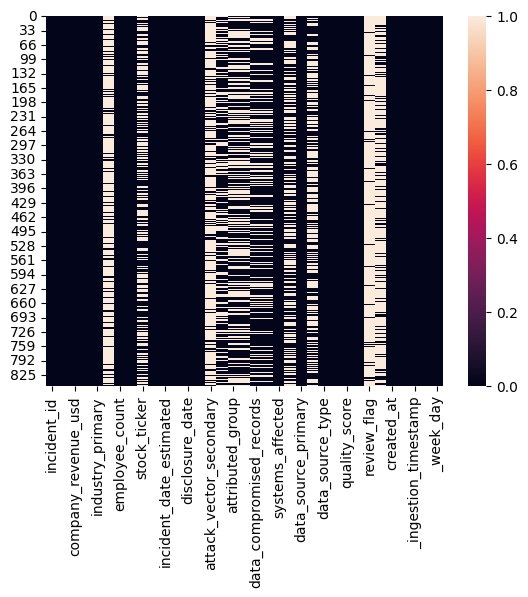

In [13]:
sns.heatmap(incedets_master_bronze.isnull())

In [14]:
print(incedets_master_bronze.duplicated(subset=['incident_id']).value_counts(),incedets_master_bronze.duplicated().sum())

False    850
Name: count, dtype: int64 0


In [15]:
incedets_master_bronze.dtypes

incident_id                            str
company_name                           str
company_revenue_usd                float64
country_hq                             str
industry_primary                       str
industry_secondary                     str
employee_count                       int64
is_public_company                     bool
stock_ticker                           str
incident_date                          str
incident_date_estimated               bool
discovery_date                         str
disclosure_date                        str
attack_vector_primary                  str
attack_vector_secondary                str
attack_chain                           str
attributed_group                       str
attribution_confidence                 str
data_compromised_records           float64
data_type                              str
systems_affected                       str
downtime_hours                     float64
data_source_primary                    str
data_source